# In cloud events of NAIS & DMPS:

Figures:

- figures S2
- figures S3

#################################################################################################

Using visability we can select for the most in-cloud events

Plot:
- NAIS 
- Cloud net & temperature (see if it is ice-dependent)
- Visibility 


In [93]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.ndimage import label
import os
from matplotlib.dates import HourLocator
import numpy as np
from datetime import datetime
import xarray as xr
from matplotlib.colors import LogNorm, Normalize
import matplotlib.dates as md
import re
import matplotlib.gridspec as gridspec
from pathlib import Path
import matplotlib as mpl
import matplotlib.ticker as ticker

plt.rcParams["font.family"] = 'monospace'

In [94]:
# Define paths relative to notebook location
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
analysis_file_path = project_root / 'Analysis' 
plots_outpath = project_root / 'Plots'

In [ ]:
def save_plot(fig, filepath, dpi=300):
    """
    Save figure to file with automatic directory creation.
    
    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object to save
    filepath : str or Path
        Full path where to save the figure (e.g., 'path/to/figure.jpeg')
    dpi : int, optional
        Resolution in dots per inch (default: 300)
    """
    filepath = Path(filepath)
    filepath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(filepath, bbox_inches='tight', dpi=dpi)
    print(f"Saved: {filepath}")

## DMPS:

In [4]:
path = r'C:\Users\Dell\Documents\NAIS_work\data\DMPS_2024'

files = glob.glob(path+'\\*')
print(files)


['C:\\Users\\Dell\\Documents\\NAIS_work\\data\\DMPS_2024\\2021_QA_QC@STP_HARMONIZED.dat', 'C:\\Users\\Dell\\Documents\\NAIS_work\\data\\DMPS_2024\\2022_QA_QC@STP_HARMONIZED.dat', 'C:\\Users\\Dell\\Documents\\NAIS_work\\data\\DMPS_2024\\2023_QA_QC@STP_HARMONIZED.dat', 'C:\\Users\\Dell\\Documents\\NAIS_work\\data\\DMPS_2024\\2024_QA_QC@STP_HARMONIZED.dat']


In [5]:
def append_data(inpath, name_in_file, all_cols, 
                datetime_cols=['YYYY', 'MM', 'DD', 'HH', 'mm']):
    DFs = []
    folder = glob.glob(inpath+'\\'+str(name_in_file)+'*.dat')
    print(folder)
    folder.sort()
    for file in folder: 
        print(file)
        ds = pd.read_csv(file, sep='\s+', 
                         skiprows=1, names=all_cols)   
        ds[datetime_cols] = ds[datetime_cols].astype(int)
        ds['DateTime'] = ds[datetime_cols].apply(lambda s : datetime(*s),axis = 1)
        ds = ds.drop(datetime_cols, axis=1)
        ds = ds.set_index('DateTime')        
        print("Size without flags removed: "+str(len(ds)))
        ds = ds[ds.loc[:,'numflag'] != 0.999] #remove these
        DFs.append(ds)
    return DFs

def concat_dfs(df_list, extras, bin_cols, flag):    
    appended_data = []
    for i in range(len(df_list)):         
        df = df_list[i]    
        appended_data.append(df)        
    appended_data = pd.concat(appended_data, sort=True)  
    appended_data = appended_data.reindex(extras + bin_cols + flag, axis=1)  
    return appended_data

def convert_df_to_ds(df, bin_cols, name=None, rename='', resample=False, resolution='h'):
    print("resolution: "+str(resolution))
    df.index.name = 'time'
    df_ = df[bin_cols].copy() #diameter is nm
    df_.columns = df_.columns.astype(float)*10**(-9)
    df_.columns.name = 'diameter'
    if resample == True:
        da = df_.stack().to_xarray().resample({'time':resolution}).mean()
    if resample == False:
        da = df_.stack().to_xarray()
    da.name=name
    ds = da.rename(rename).to_dataset()
    diameters_ = ds.diameter.values
    diameters_names = [str(np.round(x*10**9,3)) for x in diameters_]
    ds['time'] = pd.DatetimeIndex(ds['time'].values)
    ds['diameter'] = ds['diameter'].astype(float)
    return ds

<>:9: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:9: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_12624\494761442.py:9: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  ds = pd.read_csv(file, sep='\s+',


In [6]:
datetime_cols = ['YYYY', 'MM', 'DD', 'HH', 'mm']
extras = ['UFCPC','CPC3030', 'N_int', 'T', 'P', 'SAMPFLOW', 'DMA1_SHEAT', 'DMA2_SHEAT']

bin_col_names = ['5.0118723e-09', '5.6234133e-09', '6.3095734e-09',
       '7.0794578e-09', '7.9432823e-09', '8.9125094e-09', '1.0000000e-08',
       '1.1220185e-08', '1.2589254e-08', '1.4125375e-08', '1.5848932e-08',
       '1.7782794e-08', '1.9952623e-08', '2.2387211e-08', '2.5118864e-08',
       '2.8183829e-08', '3.1622777e-08', '3.5481339e-08', '3.9810717e-08',
       '4.4668359e-08', '5.0118723e-08', '5.6234133e-08', '6.3095734e-08',
       '7.0794578e-08', '7.9432823e-08', '8.9125094e-08', '1.0000000e-07',
       '1.1220185e-07', '1.2589254e-07', '1.4125375e-07', '1.5848932e-07',
       '1.7782794e-07', '1.9952623e-07', '2.2387211e-07', '2.5118864e-07',
       '2.8183829e-07', '3.1622777e-07', '3.5481339e-07', '3.9810717e-07',
       '4.4668359e-07', '5.0118723e-07', '5.6234133e-07', '6.3095734e-07',
       '7.0794578e-07']

bin_col_names_floats = [float(i)*10**9 for i in bin_col_names]
bin_cols = np.around(bin_col_names_floats, decimals=3)
bin_cols = np.asarray(bin_cols) 
bin_cols = [str(x) for x in bin_cols]
flag = ['numflag']
all_cols = datetime_cols + extras + bin_cols + flag

DFs_2021_2024 = append_data(path, name_in_file='', all_cols=all_cols)
Dps = [float(x) for x in bin_cols]
df_2021_2024 = concat_dfs(DFs_2021_2024, extras, bin_cols, flag)
df_2021_2024['P'] = df_2021_2024['P']*10**3

xr_dmps_hr = convert_df_to_ds(df_2021_2024, bin_cols, name=None, 
                              rename="dmps_number", resample=True, resolution='h')

['C:\\Users\\Dell\\Documents\\NAIS_work\\data\\DMPS_2024\\2021_QA_QC@STP_HARMONIZED.dat', 'C:\\Users\\Dell\\Documents\\NAIS_work\\data\\DMPS_2024\\2022_QA_QC@STP_HARMONIZED.dat', 'C:\\Users\\Dell\\Documents\\NAIS_work\\data\\DMPS_2024\\2023_QA_QC@STP_HARMONIZED.dat', 'C:\\Users\\Dell\\Documents\\NAIS_work\\data\\DMPS_2024\\2024_QA_QC@STP_HARMONIZED.dat']
C:\Users\Dell\Documents\NAIS_work\data\DMPS_2024\2021_QA_QC@STP_HARMONIZED.dat
Size without flags removed: 17520
C:\Users\Dell\Documents\NAIS_work\data\DMPS_2024\2022_QA_QC@STP_HARMONIZED.dat
Size without flags removed: 17520
C:\Users\Dell\Documents\NAIS_work\data\DMPS_2024\2023_QA_QC@STP_HARMONIZED.dat
Size without flags removed: 17520
C:\Users\Dell\Documents\NAIS_work\data\DMPS_2024\2024_QA_QC@STP_HARMONIZED.dat
Size without flags removed: 17568
resolution: h


In [7]:
def slice_dim_xr(ds, min_dim=None, max_dim = 2e-8):
    return ds.loc[{'diameter':slice(min_dim, max_dim)}]

def convert_to_xarray(df_merged, resolution='h', average='median', new_name="combined_number",
                      diameter_name='diameter'):
    name = None
    df_merged.index.name = 'time'
    df_merged.columns.name = diameter_name
    if average == 'median':
        da = df_merged.stack().to_xarray().resample({'time':resolution}).median()
    if average == 'mean':
        da = df_merged.stack().to_xarray().resample({'time':resolution}).mean()
    da.name=name
    ds = da.rename(new_name).to_dataset()
    ds['time'] = pd.DatetimeIndex(ds['time'].values)
    ds = ds.sortby('time')
    ds = ds.sortby(diameter_name)    
    return ds

In [8]:
xr_dmps_hr_sliced = slice_dim_xr(xr_dmps_hr, min_dim=2e-8, max_dim=None)
df_dmps = xr_dmps_hr_sliced['dmps_number'].to_pandas()
df_dmps = df_dmps.dropna(how='all')
df_dmps = xr_dmps_hr['dmps_number'].to_pandas()

ds_dmps = convert_to_xarray(df_dmps)

In [9]:
def thickax(ax, fontsize=12):
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(1.5)
    plt.rc('axes', linewidth=1.5)    
    ax = plt.gca()
    for tick in ax.xaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    for tick in ax.yaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    ax.tick_params(direction='out', length=7, width=1.5, pad=12, bottom=True, top=False, left=True, right=False)
	
def spectral_plot(xr_nais, var, title, x='time', fs_label=20, xlabel='Datetime', log_colour_scale=True, 
                  add_axis_labels=True,
                  add_colourbar_labels=False, vmin=10**(-1), vmax=10**5, diameters_ticks=None,
                  cbar_label=r'dN/dlogD$_\mathrm{p}$ [$\mathrm{cm}^{-3}$]', 
                  ylabel='D$_{\mathrm{p}}$ [m]', cmap='jet', xmin=None, xmax=None, 
                  remove_xticks=False, alpha=1, ymin=None, ymax=None, DateFormat='%H:%M', ax=None): #magma
    single_plot = False
    if ax == None:
        fig, ax = plt.subplots(figsize=(25,5))
        single_plot = True
        
    if log_colour_scale == True:
        xr_nais[var] = xr.where(xr_nais[var]==0, 10**(-100), xr_nais[var])    
        im = xr_nais[var].plot(x=x, yscale='log', norm=LogNorm(vmin=vmin,vmax=vmax), cmap=cmap, 
                                        add_colorbar=False, alpha=alpha, ax=ax)
    if log_colour_scale == False:
        im = xr_nais[var].plot(x=x, yscale='log', vmin=vmin, vmax=vmax, cmap=cmap, 
                                        add_colorbar=False, alpha=alpha, ax=ax)    
    if add_axis_labels == True:
        ax.set_ylabel(ylabel, fontsize=fs_label)
        ax.set_xlabel(xlabel, fontsize=fs_label)
        ax.set_title(title, fontsize=15, loc='left')
    
    thickax(ax, fontsize=fs_label)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    
    if remove_xticks == True:
        ax.set_xticklabels([])
       
    if add_colourbar_labels == True: 
        cb = plt.colorbar(im, orientation="vertical")
        cb.set_label(label=cbar_label, size=fs_label)
        cb.ax.tick_params(labelsize=fs_label)

    if diameters_ticks is not None:       
        yticks = [x*10**(-9) for x in diameters_ticks]
        ax.set_yticks(yticks)
        print(diameters_ticks)
        ax.set_yticklabels(diameters_ticks, fontsize=10)

    if remove_xticks == False:
        ax.xaxis.set_major_formatter(md.DateFormatter(DateFormat))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)
        plt.xticks(fontsize=14, rotation=0)

    if remove_xticks == True:
        ax.set_xticks([])
        ax.set_xticklabels([])        

    if single_plot == True:
        plt.show()
        return fig
    if single_plot == False:
        return ax

<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_12624\723120946.py:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ylabel='D$_{\mathrm{p}}$ [m]', cmap='jet', xmin=None, xmax=None,


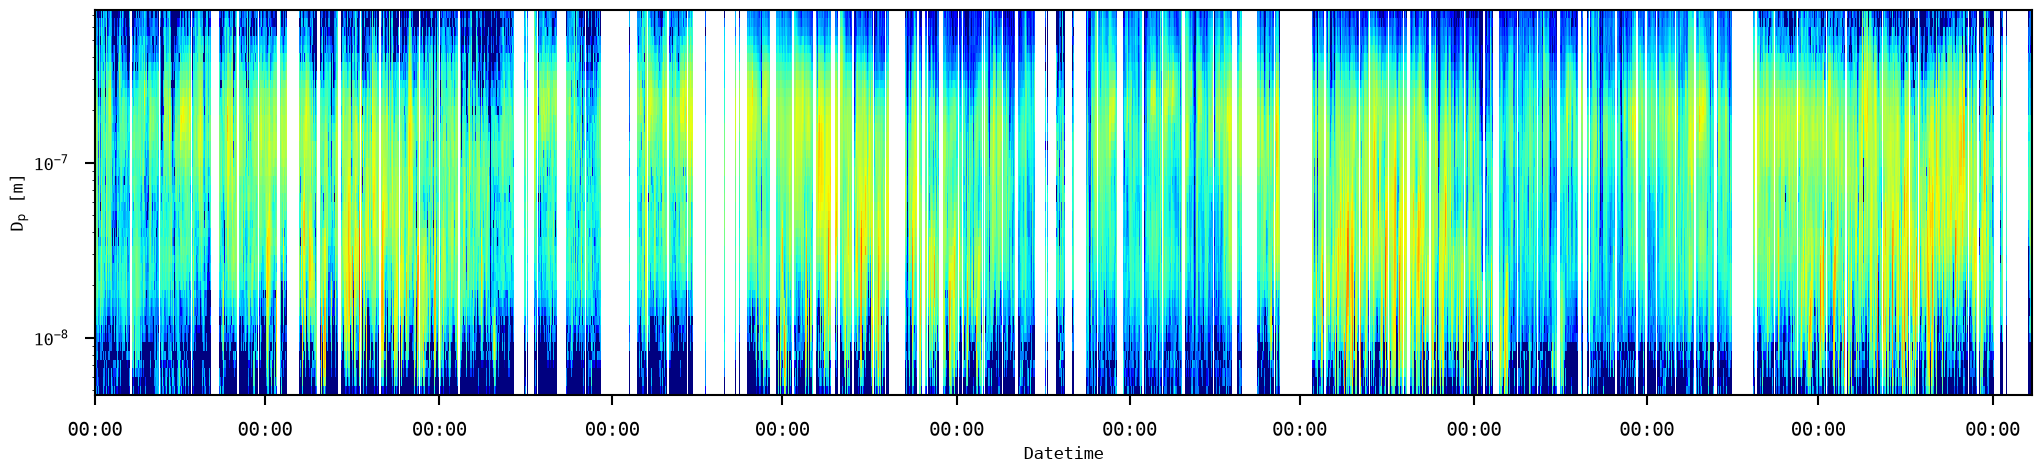

In [10]:
fig = spectral_plot(ds_dmps, var='combined_number', title='', fs_label=12, 
                xlabel='Datetime', log_colour_scale=True, ax=None)

# Cloudnet data: 

In [11]:
cloudnat_path = r'C:\Users\DominicHeslinRees\Documents\Data\CLOUDNET_NYA'

cloudnet_files = glob.glob(cloudnat_path+'\\*.nc')
print(cloudnet_files)

[]


# Webcam: 

In [98]:
webcam_path = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\photos\ZEP_webcam'

image_files = glob.glob(webcam_path+'\*')
print(image_files)

['C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\photos\\ZEP_webcam\\zeppCam2_2023-08-18T00-29-58.jpg', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\photos\\ZEP_webcam\\zeppCam2_2023-08-18T01-29-58.jpg', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\photos\\ZEP_webcam\\zeppCam2_2023-08-18T02-29-58.jpg', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\photos\\ZEP_webcam\\zeppCam2_2023-08-18T03-29-58.jpg', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\photos\\ZEP_webcam\\zeppCam2_2023-08-18T04-29-58.jpg', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\photos\\ZEP_webcam\\zeppCam2_2023-08-18T05-29-58.jpg', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\photos\\ZEP_webcam\\zeppCam2_2023-08-18T06-29-58.jpg', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\photos\\ZEP_webcam\\zeppCam2_2023-08-18T07-29-59.jpg', 'C:\\Users\\Dell\\Documents\\PythonProj

<>:3: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
<>:3: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_12624\2480349819.py:3: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
  image_files = glob.glob(webcam_path+'\*')


# Temperature: 

In [13]:
#C:\Users\Dell\Documents\AR_2025\Data\Met
# df_temp_resampled = pd.read_csv(r'C:\Users\DominicHeslinRees\NAIS_work\ZEP_processed_files\met\temp\df_temp_5T.dat',
#                                index_col=0, parse_dates=True)

df_temp_resampled = pd.read_csv(r'C:\Users\Dell\Documents\AR_2025\Data\Met\df_temp_5T.dat',
                               index_col=0, parse_dates=True)
print(df_temp_resampled.index[0])
print(df_temp_resampled.index[-1])

2022-01-01 00:00:00
2023-11-14 23:55:00


In [14]:
df_temp_resampled.head(2)

,RH,Temp,Completeness
mid_datetime,,,
2022-01-01 00:00:00,46.680000,-12.190000,100.0
2022-01-01 00:05:00,48.876667,-12.663333,100.0


# Visability: 

In [15]:
path = r'C:\Users\Dell\Documents\NAIS_work\data\visability_GCVI'
name='GCVI_vis.parquet'
df_vis = pd.read_parquet(path+'\\'+name)

print(df_vis.index[-1])

2024-10-02 07:58:55


In [16]:
df_vis_hourly = df_vis.resample('h').mean(numeric_only=True)

# Merge visability with DMPS: 

In [17]:
df_dmps = ds_dmps['combined_number'].to_pandas()
df_dmps_vis = pd.merge(df_dmps, df_vis_hourly, left_index=True, right_index=True)

In [18]:
df_dmps_vis.tail(2)

,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,vis_recv,blwr_pwr,airspdsp,covertsp,uppertsp,lowertsp,rhthresh,precsens,visthrsh,err_rprt
time,,,,,,,,,,,,,,,,,,,,,
2024-09-29 01:00:00,5.222752e-29,5.218867e-29,5.214493e-29,5.209564e-29,5.204009e-29,5.197745e-29,6.151627e-01,4.359119e+00,4.874162,4.338652,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-29 02:00:00,5.218754e-29,5.214869e-29,5.210493e-29,5.205563e-29,5.200007e-29,5.193741e-29,3.962018e-29,3.955712e-29,1.348349,5.091692,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
df_dmps_vis_outofcloud = df_dmps_vis[df_dmps_vis['visiblty'] > 5000].copy()
df_dmps_vis_incloud = df_dmps_vis[df_dmps_vis['visiblty'] < 1000].copy()

In [20]:
cols = list(df_dmps.columns)
ds_dmps_incloud = convert_to_xarray(df_dmps_vis_incloud[cols])
ds_dmps_incloud['diameter'] = ds_dmps_incloud['diameter'].astype(float)

ds_dmps_outofcloud = convert_to_xarray(df_dmps_vis_outofcloud[cols])
ds_dmps_outofcloud['diameter'] = ds_dmps_outofcloud['diameter'].astype(float)

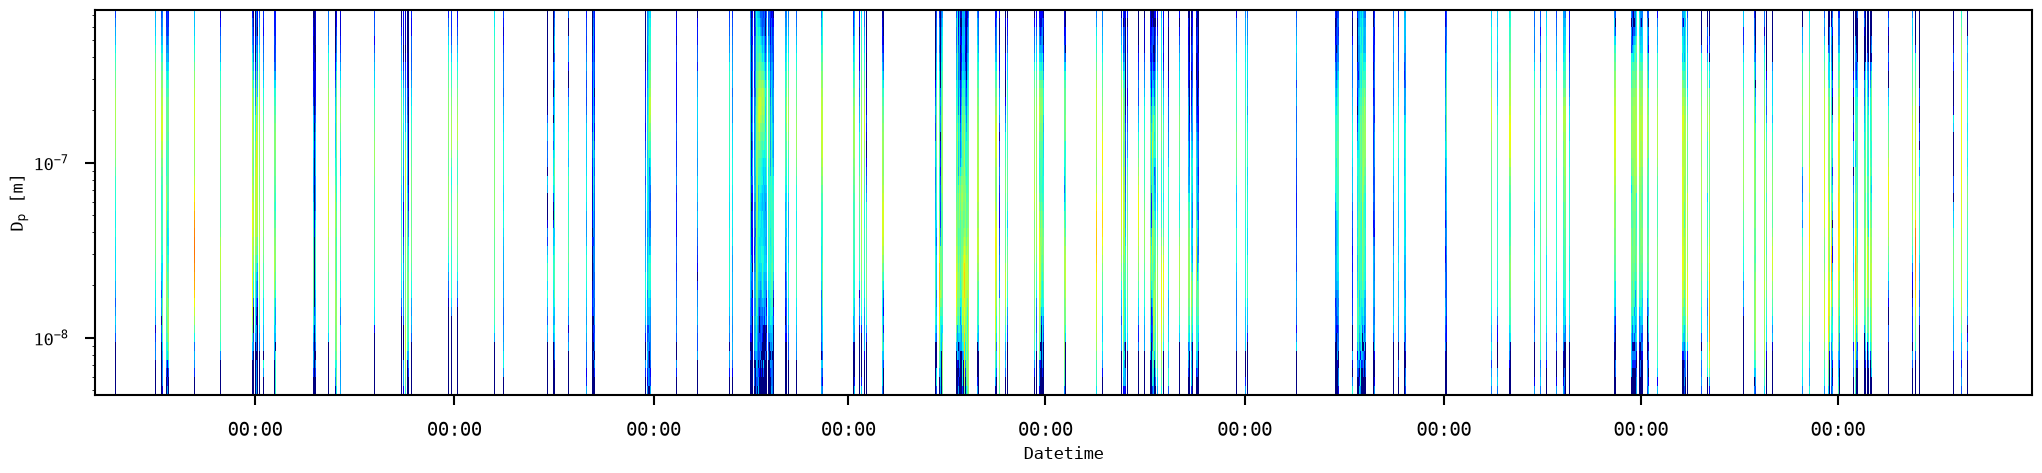

In [21]:
fig = spectral_plot(ds_dmps_incloud, var='combined_number', title='', fs_label=12, 
                xlabel='Datetime', log_colour_scale=True, ax=None)

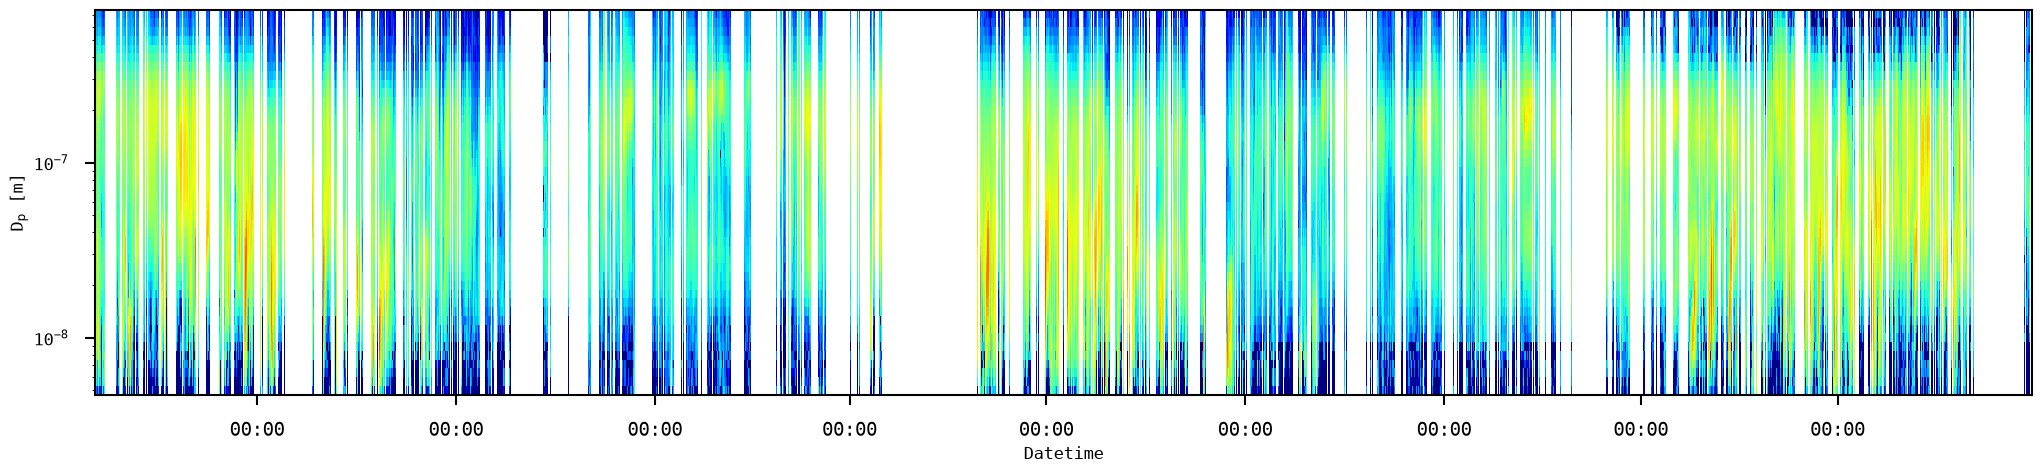

In [22]:
fig = spectral_plot(ds_dmps_outofcloud, var='combined_number', title='', fs_label=12, 
                xlabel='Datetime', log_colour_scale=True, ax=None)

## Size distribution: 

In [23]:
def plot_size_distribution(nais_xr, time_var='time', fs_label=12, 
                           ymin=10**(-1), ymax=10**4):
    fig, ax = plt.subplots(figsize=(10,5))
    nais_xr['pos_ions'].median(time_var).plot(yscale='log',xscale='log', c='r', label='+')
    nais_xr['neg_ions'].median(time_var).plot(yscale='log',xscale='log', c='b', label='-')
    ax.set_title('ions', loc='left')
    ax.set_ylabel('dN/dlogD$_\mathrm{p}$ [$\mathrm{cm}^{-3}$]', fontsize=15) 
    ax.set_xlabel('D$_{\mathrm{p}}$ [m]', fontsize=15)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='both', length=0.4, width=1)
    ax.legend(frameon=False, fontsize=25)
    ax.vlines(x=2e-9, ymin=10**(-3), ymax=1000, ls=':', color='k')
    ax.set_ylim(ymin, ymax)
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.tick_params(axis='both', which='minor', labelsize=15)
    thickax(ax, fontsize=fs_label)
    plt.show()
    return fig

<>:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_12624\3458147650.py:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_ylabel('dN/dlogD$_\mathrm{p}$ [$\mathrm{cm}^{-3}$]', fontsize=15)
C:\Users\Dell\AppData\Local\Temp\ipykernel_12624\3458147650.py:8: SyntaxWarning: "\m" is an invalid 

In [24]:
def plot_ax(ds, var='combined_number', time_var='time', c='r', label='DMPS', yscale='log', 
           title='DMPS, 2022-04-17 - 2023-02-14', fontsize=15, ymin=None, ymax=None, ls='-', 
           letter='', xtick_labels=[1,2,5,10,20,30,40], ax=None):
    
    im = ds[var].mean(time_var).plot(yscale=yscale, xscale='log', c=c, label=label, ls=ls, ax=ax)

    ax.set_title(title, loc='left')
    ax.text(s=letter, x=2.1*10**(-9), y=.5*10**4, fontsize=20)
    ax.set_ylabel('dN/dlogD$_\mathrm{p}$ [$\mathrm{cm}^{-3}$]', fontsize=15) 
    ax.set_xlabel('', fontsize=15)

    ax.tick_params(axis='both', which='both', length=0.4, width=1)
    ax.legend(frameon=False, fontsize=fontsize)
    ax.set_ylim(ymin=ymin, ymax=ymax)
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.tick_params(axis='both', which='minor', labelsize=15)
    ax.grid(True, alpha=.5, ls=':')

    if xtick_labels is not None:
       xticks = [x*10**(-9) for x in xtick_labels]
       ax.set_xticks(xticks)
       ax.set_xticklabels(xtick_labels, fontsize=fontsize)
    if xtick_labels is None:
       print("None")
       ax.set_xticklabels([], fontsize=fontsize)
    return ax

<>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_12624\4059756378.py:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_ylabel('dN/dlogD$_\mathrm{p}$ [$\mathrm{cm}^{-3}$]', fontsize=15)


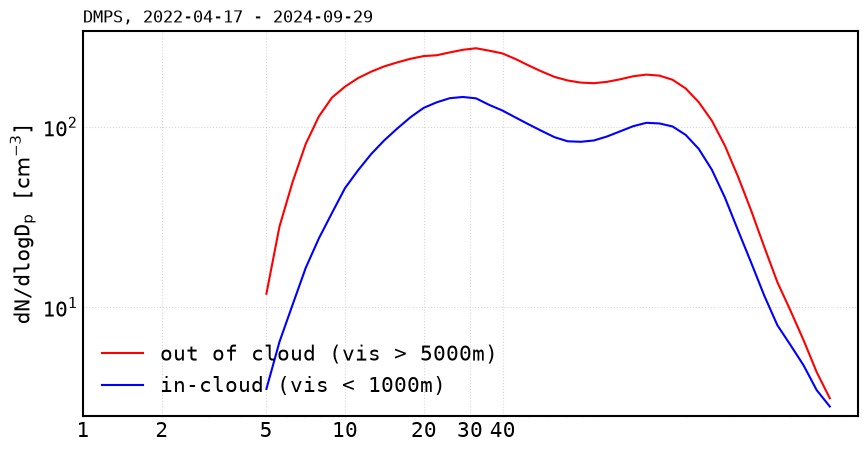

In [25]:
time_var = 'time'

fig, ax = plt.subplots(figsize=(10,5))
title='DMPS, 2022-04-17 - 2023-02-14'

start = str(pd.to_datetime(ds_dmps_outofcloud.time[0].values).date())
end = str(pd.to_datetime(ds_dmps_outofcloud.time[-1].values).date())
title='DMPS, '+str(start)+' - '+str(end)

plot_ax(ds_dmps_outofcloud, time_var='time', c='r', label='out of cloud (vis > 5000m)', yscale='log',
        title=title, xtick_labels=[1,2,5,10,20,30,40], ax=ax)
plot_ax(ds_dmps_incloud, time_var='time', c='b', label='in-cloud (vis < 1000m)', yscale='log',
        title=title, xtick_labels=[1,2,5,10,20,30,40], ax=ax)

plt.show()

# Better criteria: 

Select before and after periods of equal length

# NAIS: 

In [26]:
current_dir = r'c:\Users\DominicHeslinRees\NAIS_work'
# GRUV_inpath_files = current_dir+"\\GRUV_processed_files"
# GRUV_files = glob.glob(GRUV_inpath_files+'\\*.nc')

In [27]:
def search_resolution(inpath_files, resolution='5T', average='mean'):
    try:
        print("searching...")
        print(inpath_files+'\\*'+str(resolution)+'*'+str(average))
        resampled_files = glob.glob(inpath_files+'\\*'+str(resolution)+'*'+str(average)+'*')[0]
    except:
        resampled_files = None       
        pass
    return resampled_files

def resample_or_load(inpath_files, XR, resolution='5T', search=True,
                     savefolder=None, median=False, mean=True):                     
    if search == True:
        print("search...")
        #resolution='_'+str(resolution)
        if median == True:
            average = 'median'
        if mean == True:
            average = 'mean'
        print(average)
        file = search_resolution(inpath_files, resolution, average)
        print(file)
    if search == False:
        file = None
        
    if file:
        print("open file: "+str(file))
        XR_resampled = xr.open_dataset(file)
    if not file:
        print("resample") 
        if median == True:
            average = 'median'
        if mean == True:
            average = 'mean'  
        print(average)
        XR_resampled = resample_XR(XR, resolution, median=median, mean=mean) 
        save_xr_file(XR_resampled, inpath_files, savefolder=savefolder, 
                     filename='nais_'+str(resolution)+'_'+str(average)+'.nc')
    return XR_resampled

In [28]:
inpath_files = "C:\\Users\\Dell\\Documents\\AR_2025\\Analysis\\resampled"

ds_NAIS = resample_or_load(inpath_files, XR=None, resolution='5T', search=True) #this takes awhile
print(ds_NAIS.time[-1])

search...
mean
searching...
C:\Users\Dell\Documents\AR_2025\Analysis\resampled\*5T*mean
C:\Users\Dell\Documents\AR_2025\Analysis\resampled\nais_5T_mean.nc
open file: C:\Users\Dell\Documents\AR_2025\Analysis\resampled\nais_5T_mean.nc
<xarray.DataArray 'time' ()> Size: 8B
array('2024-10-05T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-10-05


## Merge NAIS and visability

In [29]:
df_vis_5T = df_vis.resample('5min').mean(numeric_only=True)

df_vis_5T.index.name = 'time'
ds_vis_5T = df_vis_5T['visiblty'].to_xarray()

ds_vis_5T.name='visiblty'
ds_NAIS['visiblty']=ds_vis_5T  

In [30]:
ds_NAIS_vis_outofcloud = ds_NAIS.where(ds_NAIS['visiblty'] > 5000, drop=True)

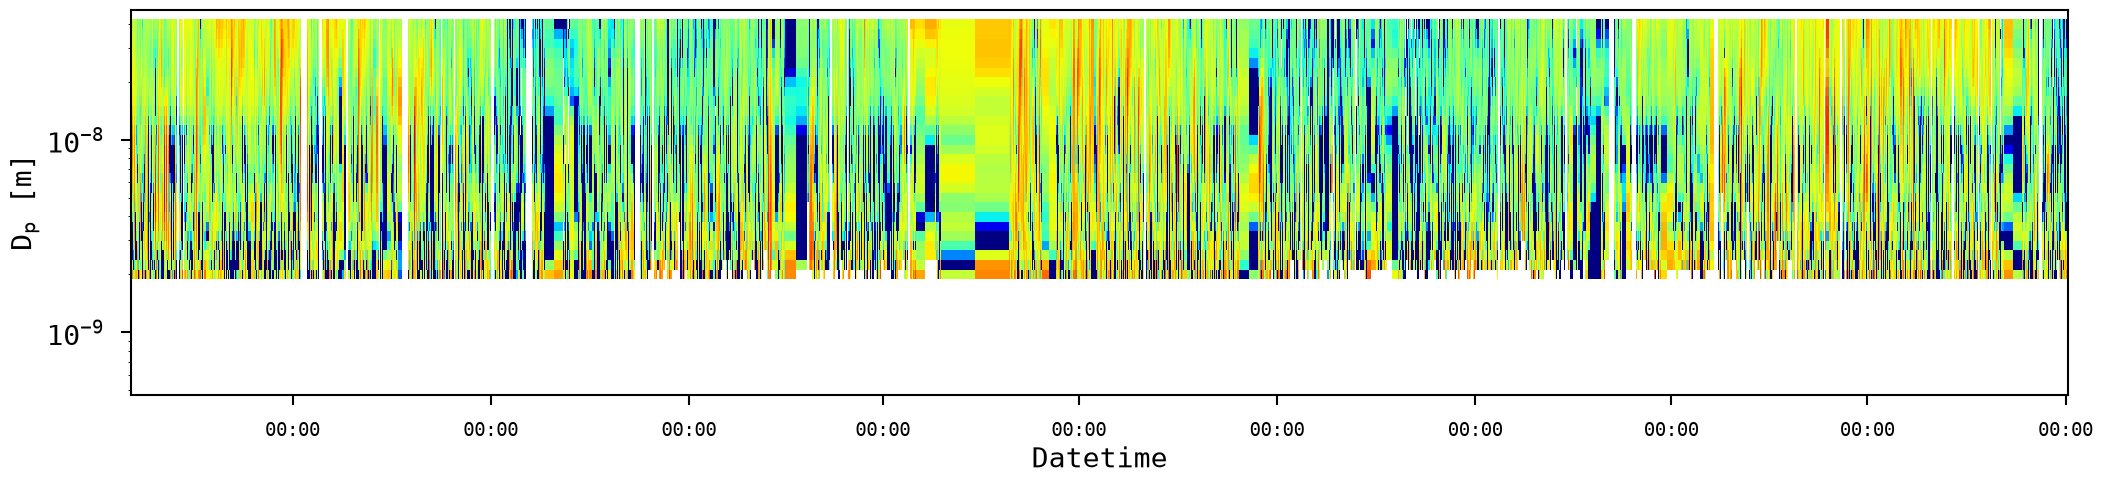

In [31]:
fig = spectral_plot(ds_NAIS_vis_outofcloud, var='neg_particles', title='', log_colour_scale=True, fs_label=20, ax=None)

In [32]:
ds_NAIS_vis_incloud = ds_NAIS.where(ds_NAIS['visiblty'] < 1000, drop=True)
#ds_NAIS_vis_incloud = ds_NAIS_vis_incloud.resample({'time':'5T'}).mean()

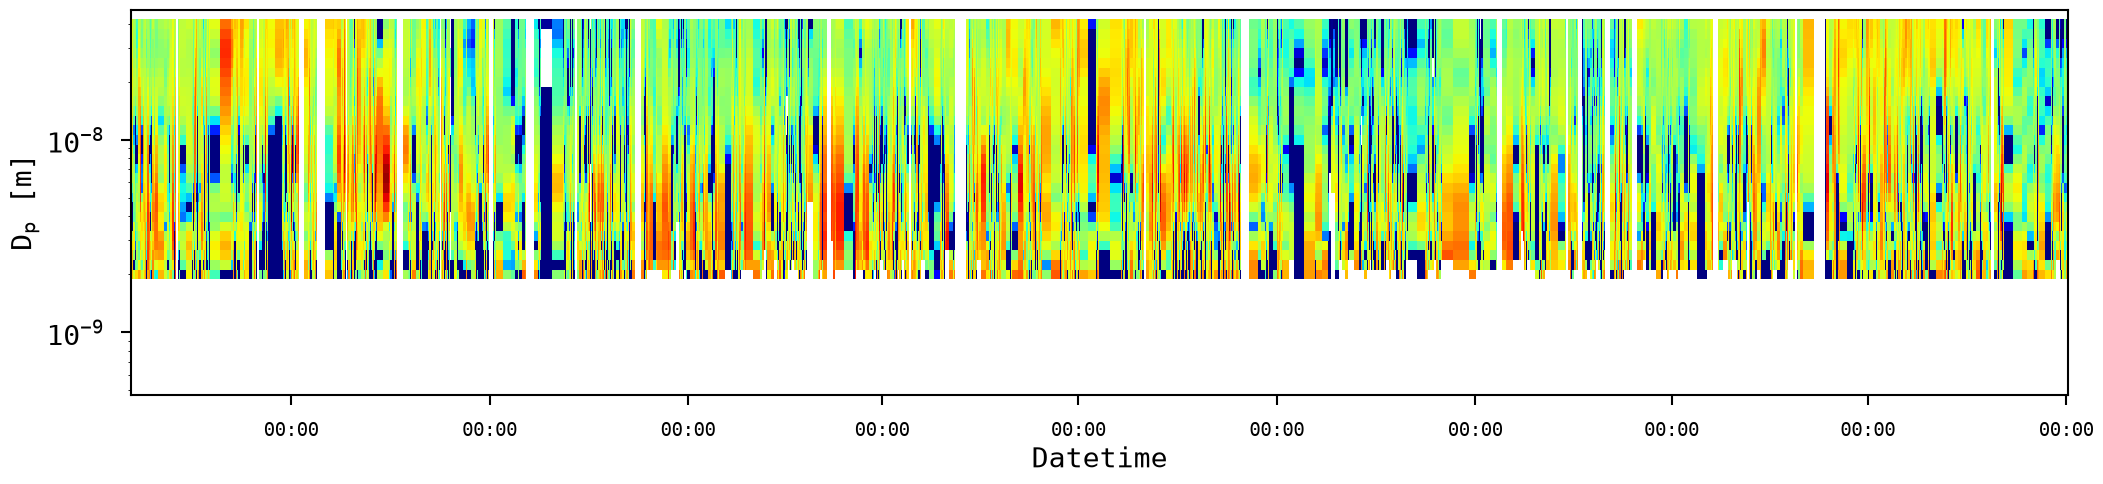

In [33]:
fig = spectral_plot(ds_NAIS_vis_incloud, var='neg_particles', title='', log_colour_scale=True, fs_label=20, ax=None)

In [34]:
ds_NAIS_vis_outofcloud

<xarray.Dataset> Size: 195MB
Dimensions:        (time: 150242, diameter: 40)
Coordinates:
  * time           (time) datetime64[ns] 1MB 2022-04-17 ... 2024-10-02T07:55:00
  * diameter       (diameter) float64 320B 5e-10 5.61e-10 ... 4.456e-08
Data variables:
    neg_ions       (time, diameter) float64 48MB nan nan nan ... 27.63 28.24 nan
    pos_ions       (time, diameter) float64 48MB nan nan nan ... 2.287 0.0 nan
    neg_particles  (time, diameter) float64 48MB nan nan nan ... 135.5 154.1 nan
    pos_particles  (time, diameter) float64 48MB nan nan nan ... 147.3 126.7 nan
    visiblty       (time) float64 1MB 3.218e+04 3.141e+04 ... 5.755e+04
Attributes: (12/14)
    measurement_location:            Zeppelin Observatory, Svalbard
    longitude:                       11.88
    latitude:                        78.9
    inlet_length:                    1.0
    do_inlet_loss_correction:        True
    convert_to_standard_conditions:  True
    ...                              ...
    use_fill_values:                 True
    fill_temperature:                0.0
    fill_pressure:                   0.0
    fill_flowrate:                   0.0
    dilution_on:                     False
    resolution:                      5min

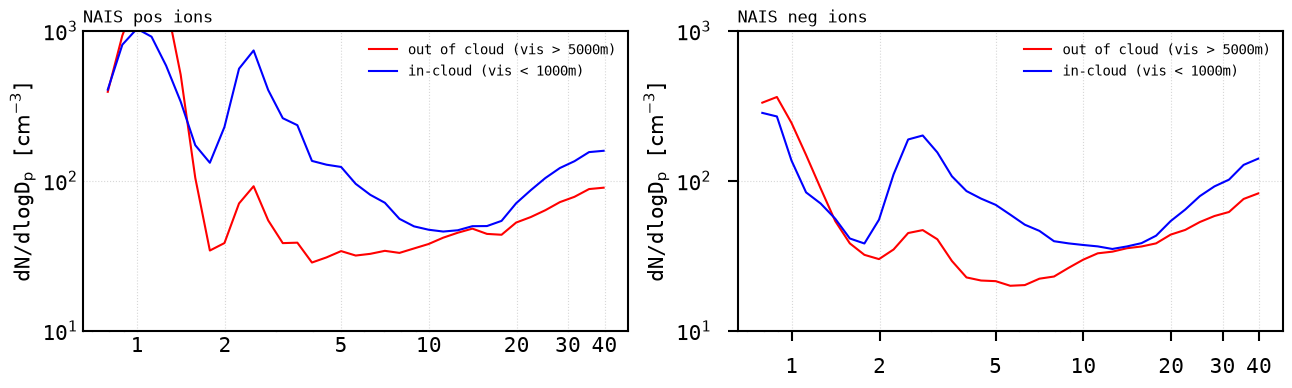

In [35]:
fig = plt.figure(figsize=(12, 3))
gs = GridSpec(1, 2, hspace = .1, wspace = .2, top = 1, bottom = 0, left = 0, right = 1)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

plot_ax(ds_NAIS_vis_outofcloud, var='pos_ions', time_var='time', c='r', label='out of cloud (vis > 5000m)', 
        yscale='linear', fontsize=10, ax=ax1)
plot_ax(ds_NAIS_vis_incloud, var='pos_ions', time_var='time', c='b', label='in-cloud (vis < 1000m)', yscale='linear', 
       title='NAIS pos ions', fontsize=10, ax=ax1)

plot_ax(ds_NAIS_vis_outofcloud, var='neg_ions', time_var='time', c='r', label='out of cloud (vis > 5000m)', 
        yscale='linear', fontsize=10, ax=ax2)
plot_ax(ds_NAIS_vis_incloud, var='neg_ions', time_var='time', c='b', label='in-cloud (vis < 1000m)', yscale='linear', 
       title='NAIS neg ions', fontsize=10, ax=ax2)

for ax in [ax1, ax2]:
    thickax(ax, fontsize=15)
    ax.set_yscale('log')
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.tick_params(axis='both', which='minor', labelsize=15)
    ax.set_ylim(10**(1), 10**3)

plt.show()

# Nano smps: 

In [36]:
loadpath = r'C:\Users\DominicHeslinRees\Documents\Data\nano_SMPS\ar_2022'
loadpath = r'C:Users\Dell\Documents\NAIS_work\data\nano_SMPS\ar_2022'

loadpath = r'C:\Users\Dell\Documents\NAIS_work\data\nano_smps\ar_2022'
filename = 'ar_2022'

#C:\Users\Dell\Documents\NAIS_work\data\nano_smps\ar_2022
df_nanosmps = pd.read_csv(loadpath+'\\'+filename+'.csv', sep=',', 
                          parse_dates=['date'], index_col=0)
df_nanosmps = df_nanosmps/(1/64)

In [37]:
nanosmps_bin_cols = df_nanosmps.columns
ds_nanosmps = convert_df_to_ds(df_nanosmps, nanosmps_bin_cols, 
                 name=None, rename='nanosmps_number')

resolution: h


In [38]:
df_nanosmps = ds_nanosmps['nanosmps_number'].to_pandas()
df_nanosmps_hourly = df_nanosmps.resample('h').mean()
df_nanosmps_vis = pd.merge(df_nanosmps_hourly, df_vis_hourly, left_index=True, right_index=True)

In [39]:
df_nanosmps_vis_outofcloud = df_nanosmps_vis[df_nanosmps_vis['visiblty'] > 5000].copy()
df_nanosmps_vis_incloud = df_nanosmps_vis[df_nanosmps_vis['visiblty'] < 1000].copy()

In [40]:
cols = list(df_nanosmps.columns)
print(cols)

ds_nanosmps_vis_incloud = convert_to_xarray(df_nanosmps_vis_incloud[cols])
ds_nanosmps_vis_outofcloud = convert_to_xarray(df_nanosmps_vis_outofcloud[cols])

[2.02e-09, 2.09e-09, 2.17e-09, 2.2500000000000003e-09, 2.33e-09, 2.41e-09, 2.5e-09, 2.59e-09, 2.69e-09, 2.79e-09, 2.89e-09, 3.0000000000000004e-09, 3.1100000000000002e-09, 3.2200000000000005e-09, 3.34e-09, 3.46e-09, 3.5900000000000002e-09, 3.7200000000000004e-09, 3.8500000000000006e-09, 4e-09, 4.14e-09, 4.290000000000001e-09, 4.45e-09, 4.6100000000000004e-09, 4.7800000000000005e-09, 4.96e-09, 5.14e-09, 5.33e-09, 5.52e-09, 5.730000000000001e-09, 5.9400000000000006e-09, 6.1500000000000005e-09, 6.38e-09, 6.610000000000001e-09, 6.85e-09, 7.1e-09, 7.370000000000001e-09, 7.640000000000001e-09, 7.910000000000001e-09, 8.199999999999999e-09, 8.51e-09, 8.82e-09, 9.140000000000001e-09, 9.470000000000001e-09, 9.820000000000001e-09, 1.02e-08, 1.06e-08, 1.0900000000000002e-08, 1.1300000000000002e-08, 1.1800000000000001e-08, 1.22e-08, 1.26e-08, 1.31e-08, 1.3600000000000001e-08, 1.41e-08, 1.46e-08, 1.51e-08, 1.57e-08, 1.63e-08, 1.68e-08, 1.75e-08, 1.8100000000000003e-08, 1.8800000000000003e-08, 1.9500

In [41]:
ds_nanosmps_vis_incloud['diameter'] = ds_nanosmps_vis_incloud['diameter'].astype(float)
ds_nanosmps_vis_outofcloud['diameter'] = ds_nanosmps_vis_outofcloud['diameter'].astype(float)

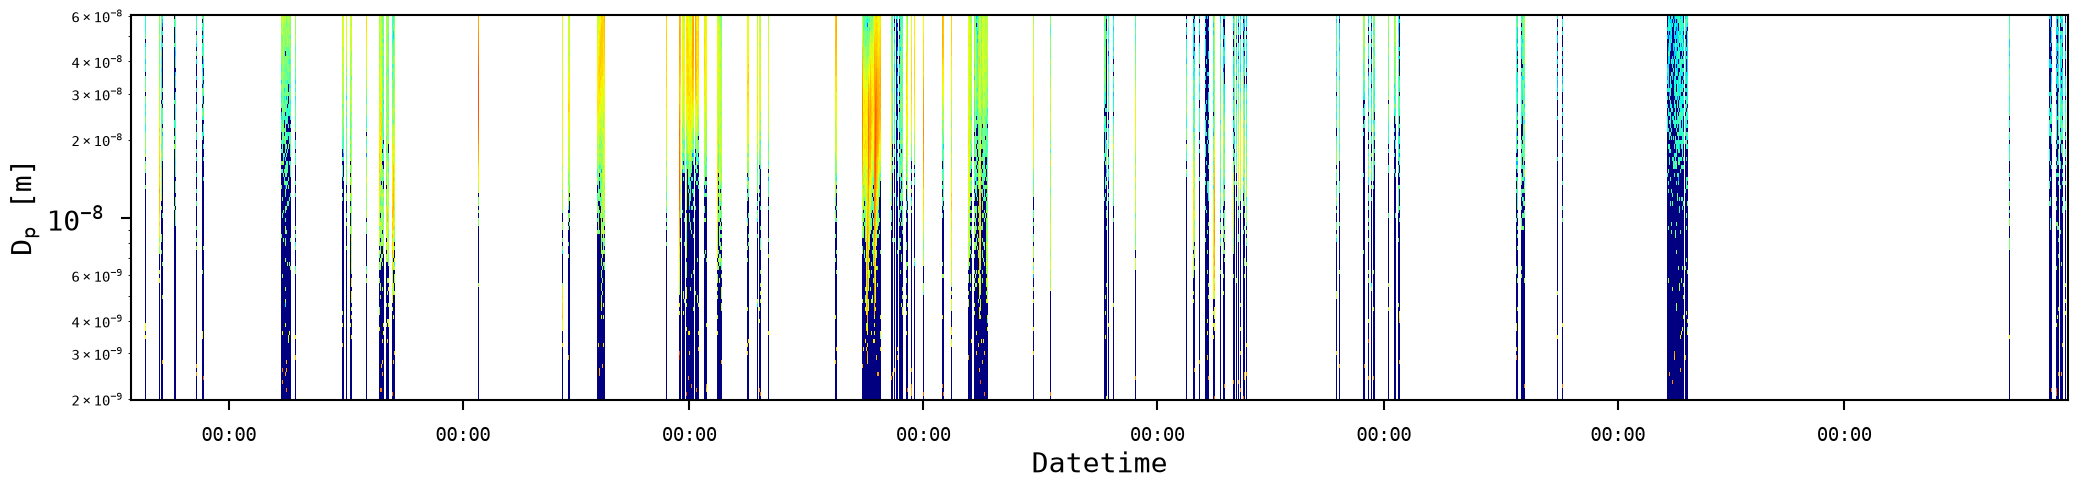

In [42]:
fig = spectral_plot(ds_nanosmps_vis_incloud, var='combined_number', title='', fs_label=20, 
                xlabel='Datetime', log_colour_scale=True)

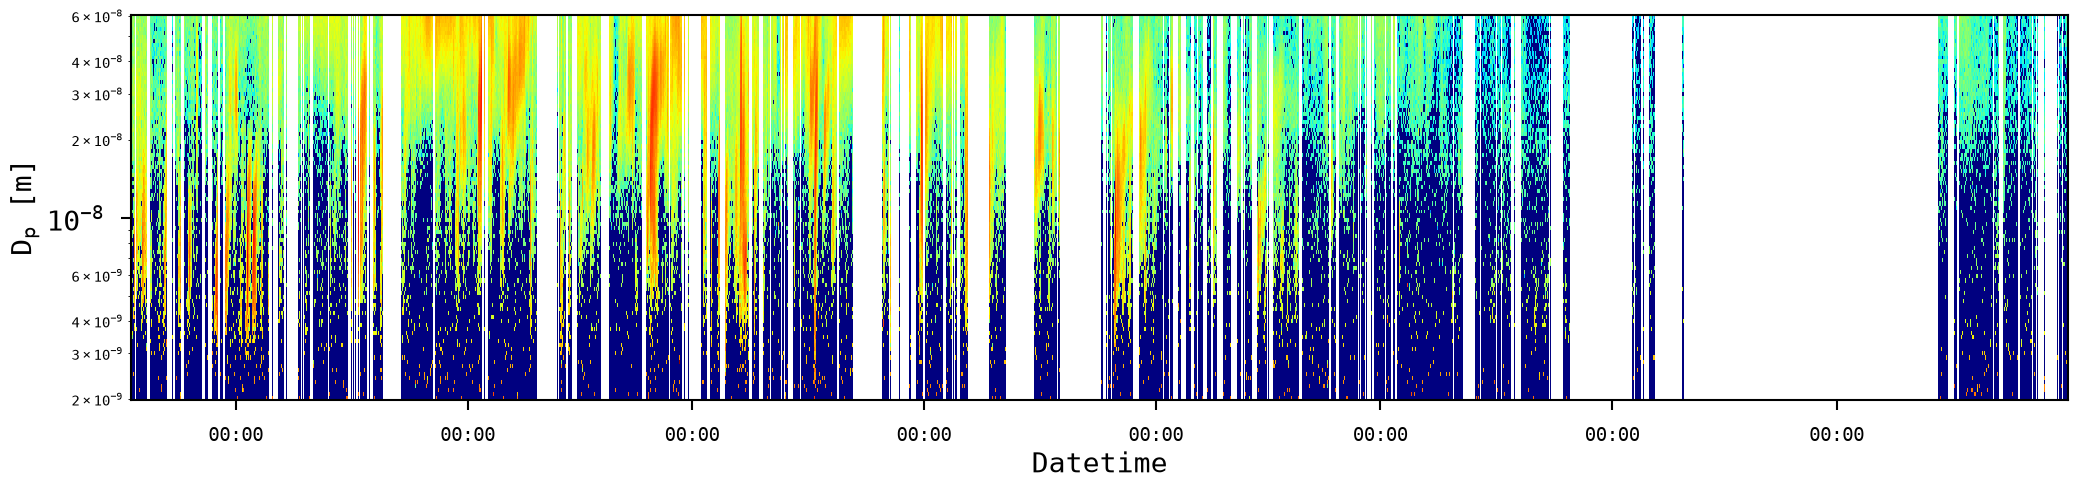

In [43]:
fig = spectral_plot(ds_nanosmps_vis_outofcloud, var='combined_number', title='', fs_label=20, 
                xlabel='Datetime', log_colour_scale=True)

In [44]:
def unstack_day(ds):
    return (
        ds
        .assign_coords(t=(lambda d: d['time']))
        .assign_coords(day=(lambda d: d['time'].dt.floor('1D')))
        .assign_coords(
            hour=(lambda d: (d['time'] - d['day']) / pd.Timedelta('1H')))
        .set_index({'time': ['day', 'hour']})
        .unstack('time')
    )

In [45]:
ds_nanosmps_vis_outofcloud = unstack_day(ds_nanosmps_vis_outofcloud)
ds_nanosmps_vis_incloud = unstack_day(ds_nanosmps_vis_incloud)

C:\Users\Dell\AppData\Local\Temp\ipykernel_12624\2936848939.py:7: Pandas4Warning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  hour=(lambda d: (d['time'] - d['day']) / pd.Timedelta('1H')))
C:\Users\Dell\AppData\Local\Temp\ipykernel_12624\2936848939.py:7: Pandas4Warning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  hour=(lambda d: (d['time'] - d['day']) / pd.Timedelta('1H')))


In [46]:
ds_diurnal_nanosmps_vis_outofcloud = ds_nanosmps_vis_outofcloud.groupby('t.hour').mean()
ds_diurnal_nanosmps_vis_incloud = ds_nanosmps_vis_incloud.groupby('t.hour').mean()

[1, 2, 5, 10, 20, 50, 100]


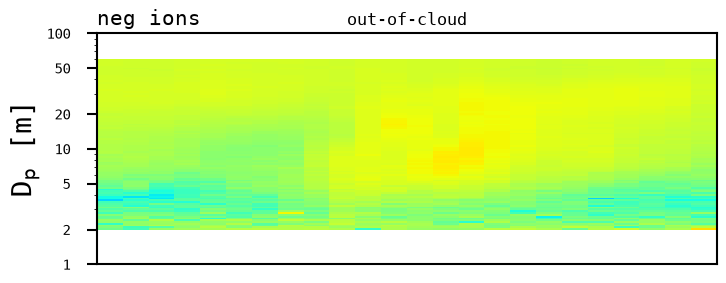

In [47]:
fig, ax = plt.subplots(figsize=(8, 3))
spectral_plot(ds_diurnal_nanosmps_vis_outofcloud, var='combined_number', title='neg ions',  
              x='hour', xlabel='', diameters_ticks=[1, 2, 5, 10, 20, 50, 100], ax=ax)
ax.set_title('out-of-cloud')
ax.set_xticks([])
plt.show()

In [48]:
min_value = ds_diurnal_nanosmps_vis_outofcloud['combined_number'].min()
print(min_value)
ds_diurnal_nanosmps_vis_outofcloud = ds_diurnal_nanosmps_vis_outofcloud.where(ds_diurnal_nanosmps_vis_outofcloud['combined_number'] != min_value)

<xarray.DataArray 'combined_number' ()> Size: 8B
array(9.37893066)


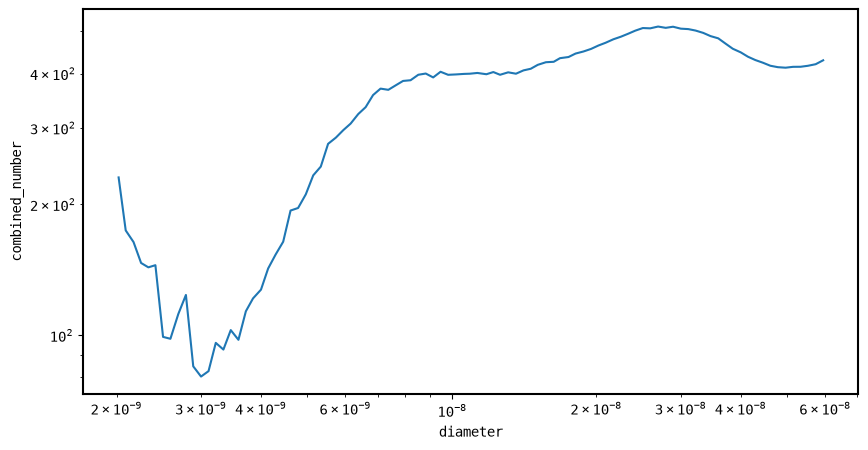

In [49]:
fig, ax = plt.subplots(figsize=(10,5))
ds_diurnal_nanosmps_vis_outofcloud['combined_number'].mean('hour').plot(yscale='log', xscale='log', label='nano SMPS (out of cloud)')
plt.show()

<>:5: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:5: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_12624\2555342045.py:5: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_ylabel('dN/dlogD$_\mathrm{p}$ [$\mathrm{cm}^{-3}$]', fontsize=15)
C:\Users\Dell\AppData\Local\Temp\ipykernel_12624\2555342045.py:6: SyntaxWarning: "\m" is an invalid 

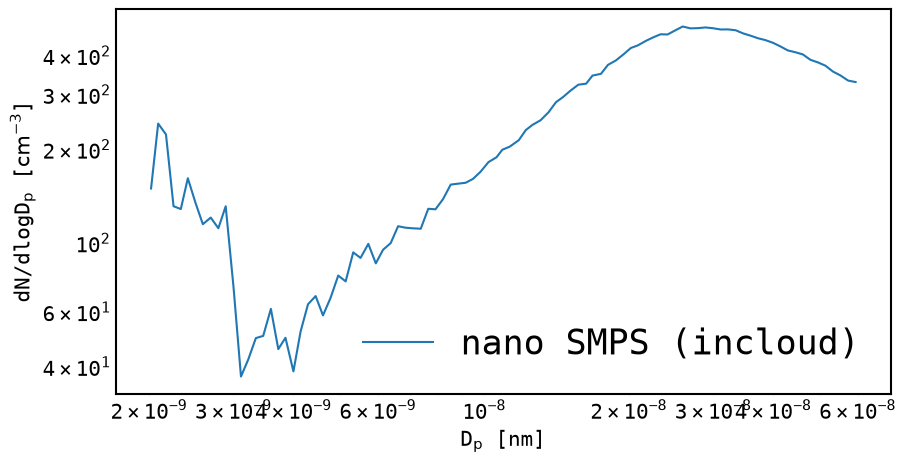

In [50]:
fig, ax = plt.subplots(figsize=(10,5))

ds_diurnal_nanosmps_vis_incloud['combined_number'].mean('hour').plot(yscale='log', xscale='log', label='nano SMPS (incloud)')

ax.set_ylabel('dN/dlogD$_\mathrm{p}$ [$\mathrm{cm}^{-3}$]', fontsize=15) 
ax.set_xlabel('D$_{\mathrm{p}}$ [nm]', fontsize=15)
# ax.minorticks_on()
ax.tick_params(axis='both', which='both', length=0.4, width=1)
ax.legend(frameon=False, fontsize=25)
#ax.set_ylim(ymin=10**(-1), ymax=10**(1))
ax.tick_params(axis='both', which='major', labelsize=15)
ax.tick_params(axis='both', which='minor', labelsize=15)    

# xticks = [1,2,5,10,20,30,40,] #nm
# xticks = [x*10**(-9) for x in xticks]
# ax.set_xticks(xticks)
# ax.set_xticklabels([1,2,5,10,20,30,40, ], fontsize=15)
# thickax(ax, fontsize=15)
plt.show()

<>:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_12624\3156493774.py:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_ylabel('dN/dlogD$_\mathrm{p}$ [$\mathrm{cm}^{-3}$]', fontsize=15)
C:\Users\Dell\AppData\Local\Temp\ipykernel_12624\3156493774.py:9: SyntaxWarning: "\m" is an invalid 

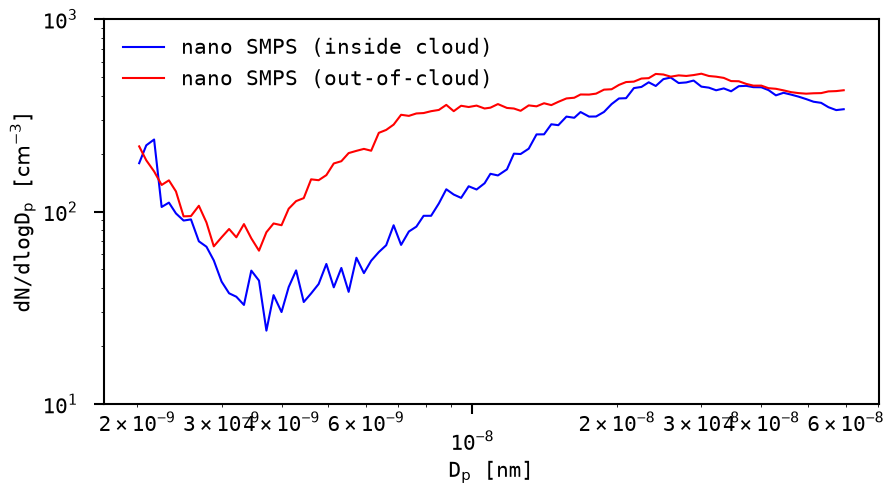

In [51]:
fig, ax = plt.subplots(figsize=(10,5))

ds_diurnal_nanosmps_vis_incloud['combined_number'].median('hour').plot(yscale='log', xscale='log', 
                                                               label='nano SMPS (inside cloud)', color='b')
ds_diurnal_nanosmps_vis_outofcloud['combined_number'].median('hour').plot(yscale='log', xscale='log', 
                                                                          label='nano SMPS (out-of-cloud)', color='r')

ax.set_ylabel('dN/dlogD$_\mathrm{p}$ [$\mathrm{cm}^{-3}$]', fontsize=15) 
ax.set_xlabel('D$_{\mathrm{p}}$ [nm]', fontsize=15)

ax.legend(frameon=False, fontsize=15)
ax.set_ylim(ymin=10**(1), ymax=10**(3))
ax.tick_params(axis='both', which='major', labelsize=15)
ax.tick_params(axis='both', which='minor', labelsize=15)    

thickax(ax, fontsize=15)
plt.show()

## Figures S3:

<>:38: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:38: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_12624\2105249528.py:38: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  fig.text(0.5, 0.01, 'D$_{\mathrm{p}}$ [nm]', ha='center', fontsize=20)


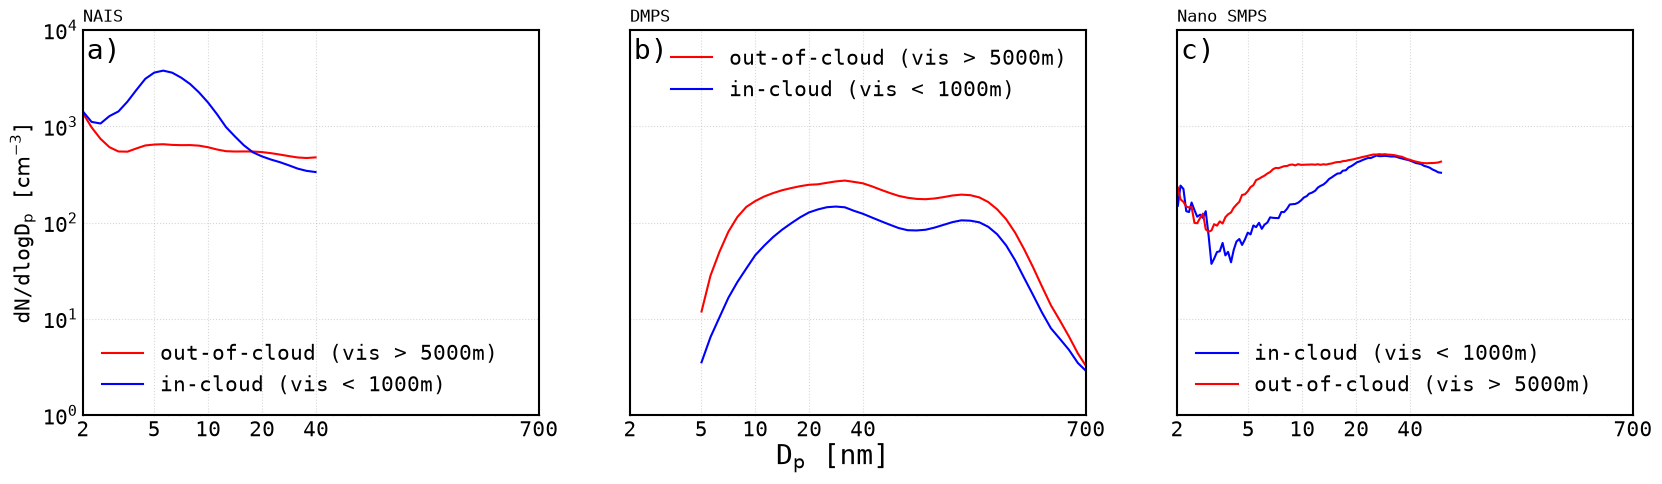

Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots\FigureS3.jpeg


In [52]:
fig, (ax1,ax2, ax3) = plt.subplots(1, 3, figsize=(20,5), sharey=True, sharex=True)

plot_ax(ds_NAIS_vis_outofcloud, var='neg_particles', time_var='time', c='r', label='out-of-cloud (vis > 5000m)', 
        yscale='log', ymax=10**3, letter='a)', ax=ax1)
plot_ax(ds_NAIS_vis_incloud, var='neg_particles', time_var='time', c='b', label='in-cloud (vis < 1000m)', 
        yscale='log', title='NAIS', ymax=10**3, ax=ax1)

plot_ax(ds_dmps_outofcloud, time_var='time', c='r', label='out-of-cloud (vis > 5000m)', yscale='log',
        title='DMPS',  letter='b)', ax=ax2)
plot_ax(ds_dmps_incloud, time_var='time', c='b', label='in-cloud (vis < 1000m)', yscale='log',
        title='DMPS', ax=ax2)
ax2.set_ylabel('', fontsize=15) 

ds_diurnal_nanosmps_vis_incloud['combined_number'].mean('hour').plot(yscale='log', xscale='log', 
                                                label='in-cloud (vis < 1000m)', color='b', ax=ax3)
ds_diurnal_nanosmps_vis_outofcloud['combined_number'].mean('hour').plot(yscale='log', xscale='log', 
                                                label='out-of-cloud (vis > 5000m)', color='r', ax=ax3)
ax3.text(s='c)', x=2.1*10**(-9), y=.5*10**4, fontsize=20)

ax3.set_title('Nano SMPS', loc='left')
ax3.set_ylabel('', fontsize=15) 
ax3.set_xlabel('', fontsize=15)
#ax3.minorticks_on()
ax3.tick_params(axis='both', which='both', length=0.4, width=1)
ax3.legend(frameon=False, fontsize=15)
ax3.tick_params(axis='both', which='major', labelsize=15)
ax3.tick_params(axis='both', which='minor', labelsize=15)    
xticks = [1,2,5,10,20,40, 700] #nm
xticks = [x*10**(-9) for x in xticks]
ax3.set_xticks(xticks)
ax3.set_xticklabels([1,2,5,10,20,40, 700], fontsize=15)
ax3.grid(True, alpha=.5, ls=':')

for ax in [ax1, ax2, ax3]:
        #thickax(ax, fontsize=15)
        ax.set_ylim(ymin=10**(0), ymax=10**(4))        
        ax.set_xlim(2*10**(-9), 700*10**(-9))
fig.text(0.5, 0.01, 'D$_{\mathrm{p}}$ [nm]', ha='center', fontsize=20)

plt.show()


output_figure = plots_outpath / 'FigureS3.jpeg'
save_plot(fig, output_figure)

In [53]:
def compare_nais_nanosmps(file):
    nais_ = xr.open_dataset(file) 
    ds_nanosmps_day = ds_nanosmps.sel(time=slice(nais_.time[0], nais_.time[-1]))

    fig = spectral_plot(nais_, var='neg_particles', title='', log_colour_scale=True, fs_label=20, ax=None)
    fig = spectral_plot(ds_nanosmps_day, var='nanosmps_number', title='', fs_label=20, 
                    xlabel='Datetime', log_colour_scale=True)

# Rain & cloud events: 

rank visiability by number of hours where vis is below 1000 m 

In [54]:
def make_binary_conditions(df):
    df['cloud'] = df['visiblty'].apply(lambda x: 1 if x < 1000 else 0)
    return df

In [55]:
df_vis.head(2)

,visiblty,cloudstt,precstat,airspeed,humidity,temperat,covertmp,coverpwr,uppertmp,upperpwr,...,airspdsp,covertsp,uppertsp,lowertsp,rhthresh,precsens,ignrprec,visthrsh,err_rprt,savedata
datetime,,,,,,,,,,,,,,,,,,,,,
2022-04-17 00:00:00,33985,NaN,NaN,0,93,-10.5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-04-17 00:00:01,33993,NaN,NaN,0,93,-10.4,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
df_vis_5T = df_vis[['visiblty']].resample('5min').mean()
df_vis_5T = make_binary_conditions(df_vis_5T) #turn vis into a binary value

df_vis_5T['date'] = df_vis_5T.index.date

# Wind: 

In [57]:
def resample_wind(df_wind, time_resolution='5T'):
    df_wind[['WindDirection']] = df_wind[['WindDirection']].dropna(how='any')
    df_wind[['WindSpeed']] = df_wind[['WindSpeed']].dropna(how='any')

    df_winddirection_hr = df_wind[['WindDirection']].resample(time_resolution).apply(average_wind_direction)
    df_windspeed_hr = df_wind[['WindSpeed']].resample(time_resolution).mean()

    df_wind_hr = pd.concat([df_winddirection_hr, df_windspeed_hr], axis=1)
    return df_wind_hr

In [62]:
def resample_or_load_winddf(inpath_files, df_wind, resolution='5T', search=True, mean=True):
    if search == True:
        file = search_resolution(inpath_files+"\\resampled", resolution, average='mean')
    if search == False:
        file = None    
    file = search_resolution(inpath_files+"\\resampled", resolution, average='mean')
    print("search: "+inpath_files)
    print(file)
    if file:
        print("load/open file")
        df_wind_resampled = pd.read_csv(file, parse_dates=True, index_col=0)
    if not file:  
        if mean == True:
            average = 'mean'
        print("resampling file as resampled file not found in "+str(inpath_files))
        df_wind_resampled = resample_wind(df_wind, time_resolution='5T')
        print(inpath_files+"\\resampled")
        save_df(df_wind_resampled, inpath_files+"\\resampled", 
        name='df_wind_'+str(resolution)+'_'+str(average), index=True, float_format=None)
    return df_wind_resampled

In [63]:
loadpath_wind = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Data\met'
df_wind_resampled = resample_or_load_winddf(loadpath_wind, df_wind=None, resolution='5T', 
                                            search=True) #5minutes

searching...
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Data\met\resampled\*5T*mean
searching...
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Data\met\resampled\*5T*mean
search: C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Data\met
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Data\met\resampled\df_wind_5T_mean.dat
load/open file


In [64]:
def make_binary_conditions_wind(df, wind_threshold=5):
    df['windblown'] = df['WindSpeed'].apply(lambda x: 1 if x > wind_threshold else 0)
    return df

df_wind_resampled = make_binary_conditions_wind(df_wind_resampled)
df_wind_resampled['date'] = df_wind_resampled.index.date

In [66]:
df_wind_resampled.head(2)

,WindDirection,WindSpeed,windblown,date
mid_datetime,,,,
2022-01-01 00:00:00,145.196304,1.806381,0,2022-01-01
2022-01-01 00:05:00,30.475836,1.040633,0,2022-01-01


## In cloud events: 

In [67]:
number_of_data_points = df_vis_5T[['cloud', 'date']].groupby('date').count()['cloud']
sum_of_cloud_points = df_vis_5T[['cloud', 'date']].groupby('date').sum()['cloud']

df_percentage_cloud = sum_of_cloud_points/number_of_data_points

df_percentage_cloud = df_percentage_cloud.to_frame()
df_percentage_cloud['number_of_points'] = number_of_data_points
df_percentage_cloud['sum_of_cloud_points'] = sum_of_cloud_points

df_percentage_cloud = df_percentage_cloud[df_percentage_cloud>0]
df_percentage_cloud = df_percentage_cloud.dropna(how='any')

df_percentage_cloud = df_percentage_cloud.sort_values('cloud', ascending=False)

In [68]:
df_percentage_cloud.head(2)

,cloud,number_of_points,sum_of_cloud_points
date,,,
2022-07-24,1.0,288,288.0
2022-11-08,1.0,288,288.0


In [69]:
dates = df_percentage_cloud.index

inpath_files = current_dir+"\\ZEP_processed_files"
ZEP_files = glob.glob(inpath_files+'\\*.nc')
outpath_plots=current_dir+"\\plots\\daily_plots\\cloud"

In [70]:
df_temp_resampled.head(2)

,RH,Temp,Completeness
mid_datetime,,,
2022-01-01 00:00:00,46.680000,-12.190000,100.0
2022-01-01 00:05:00,48.876667,-12.663333,100.0


In [71]:
def temp_plot(df, var='Temp', varlabel='T [$\degree$C]', date=None, 
            fontsize=12, ax=None):
    single_plot = False
    if ax == None:
        fig, ax = plt.subplots(figsize=(25,5))
        single_plot = True
    ax.plot(df.index, df[var], 'o', mec='k', mfc='k', linewidth=3, ms=3)
    date_form = DateFormatter("%H")
    ax.xaxis.set_major_formatter(date_form)
    if date is not None:
        plt.xlim(pd.to_datetime(date), pd.to_datetime(date)+timedelta(days=1))   
    fancy(ax, fontsize=fontsize) 
    ax.set_ylabel(varlabel, fontsize=fontsize)    
    #ax.set_yscale('log')
    #ax.set_ylim(10, 10**5)
    ax.axhline(0, ls=':', c='r', lw=1, label='zero')
    ax.legend(frameon=False)    
    if single_plot == True:
        plt.show()
        return fig
    if single_plot == False:
        return ax

<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_12624\1503643685.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  def temp_plot(df, var='Temp', varlabel='T [$\degree$C]', date=None,


In [72]:
def select_day(ds_dmps_2022_2024, event, var='dmps_number'):
    df_dmps_2022_2024 = ds_dmps_2022_2024[var].to_pandas()
    df_dmps_2022_2024['date'] = df_dmps_2022_2024.index.date.astype(str)
    df_dmps_2022_2024_dmps = df_dmps_2022_2024[df_dmps_2022_2024['date'] == str(event)]
    df_dmps_2022_2024_dmps = df_dmps_2022_2024_dmps.drop(columns=['date'])
    df_pnsd = df_dmps_2022_2024_dmps.copy()
    df_pnsd.columns = bin_cols
    ds_pnsd = convert_df_to_ds(df_pnsd, bin_cols, name=None, rename=var, resample=False)
    return ds_pnsd

In [73]:
start_loc = 0.01
loc_list = [(1/6)*x for x in np.arange(1, 7)]
print(loc_list)
loc_list.insert(0, 0)
print(loc_list)
loc_list_mid = [(loc_list[i]+loc_list[i+1])/2 for i in np.arange(0, 6)]
print(loc_list_mid)

[np.float64(0.16666666666666666), np.float64(0.3333333333333333), np.float64(0.5), np.float64(0.6666666666666666), np.float64(0.8333333333333333), np.float64(1.0)]
[0, np.float64(0.16666666666666666), np.float64(0.3333333333333333), np.float64(0.5), np.float64(0.6666666666666666), np.float64(0.8333333333333333), np.float64(1.0)]
[np.float64(0.08333333333333333), np.float64(0.25), np.float64(0.41666666666666663), np.float64(0.5833333333333333), np.float64(0.75), np.float64(0.9166666666666666)]


In [74]:
def plot_decoupled(event, ZEP_files, df_temp, df_vis, ds_dmps_2022_2024=None, var='combined_number',
                ranking='', fontsize=12, add_cf=True, polarity='neg', quantile=.99):
    
    string_event = str(event)[:10].replace('-','')
    fig = plt.figure(figsize=(8, 10))    
    gs = gridspec.GridSpec(nrows=8, ncols=13, hspace = .5, wspace = 12, top = 1,
                       bottom = 0, left = 0, right = 1)
    #############CLOUDNET######################################################################
    ax1 = fig.add_subplot(gs[0, 0:11])    
    ax1.set_title(event) #, +' channel: '+str(polarity)+', cloud length ranking: '+str(ranking)) #a ranking perhaps
    ax1.text(1.01, .75, s='a)', size=15, color='k', transform=ax1.transAxes)
    try:
        digit_files = [get_digits(x) for x in cloudnet_files]
        index = digit_files.index(string_event)
        cloudnet_file = cloudnet_files[index]
        xr_cloudnet = xr.open_dataset(cloudnet_file)
        plot_cloudnet(xr_cloudnet, date=None, fontsize=12, varlabel='Height [m]', ax=ax1)
    except:
        pass
    ###########TEMP############################################################################
    ax2 = fig.add_subplot(gs[1, 0:11])
    ax2.text(1.01, .75, s='b)', size=15, color='k', transform=ax2.transAxes)
    try:
        temp_plot(df_temp, ax=ax2)
    except:
        pass
    ax2.set_xticklabels([])              
    for ax in [ax1, ax2]:
        ax.set_xticks([])      
    ############TEMP############################################################################
    ax3 = fig.add_subplot(gs[2, 0:11])   
    ax3.text(1.01, .75, s='c)', size=15, color='k', transform=ax3.transAxes) 
    try:
        vis_plot(df_vis, ax=ax3)
    except:
        pass
    ax3.set_xticklabels([])
    ax3.set_xticks([])        
    
    ############WEBCAM###########################################################################
    #0 - 4
    loc_list = [(1/6)*x for x in np.arange(1, 7)]
    loc_list.insert(0, 0)
    loc_list_mid = [(loc_list[i]+loc_list[i+1])/2 for i in np.arange(0, 6)]

    ax4 = fig.add_subplot(gs[3, 0:11]) #nrows, ncols
    #ax4.text(1.01, .75, s='d)', size=15, color='k', transform=ax.transAxes)
    datetime = pd.to_datetime(str(event)+' 02:00:00')
    try:
        image_file = get_file_from_datetime(image_files, datetime)
        img = mpimg.imread(image_file)
        plt.xlim(0,1)
        ax4.imshow(img, extent=[0,0.167,0,1], aspect='auto')
    except ValueError:
        pass                
    #4 - 8
    datetime = pd.to_datetime(str(event)+' 06:00:00')
    try:
        image_file = get_file_from_datetime(image_files, datetime)
        img = mpimg.imread(image_file)
        ax4.imshow(img, extent=[0.167,0.33,0,1], aspect='auto')
    except ValueError:
        pass    
    #8 - 12
    datetime = pd.to_datetime(str(event)+' 10:00:00')
    try:
        image_file = get_file_from_datetime(image_files, datetime)
        img = mpimg.imread(image_file)
        ax4.imshow(img, extent=[0.33,0.5,0,1], aspect='auto')
    except ValueError:
        pass    
    #12 - 16
    datetime = pd.to_datetime(str(event)+' 14:00:00')
    try:
        image_file = get_file_from_datetime(image_files, datetime)
        img = mpimg.imread(image_file)
        ax4.imshow(img, extent=[0.5,0.667,0,1], aspect='auto')
    except ValueError:
        pass
    #16 - 20    
    datetime = pd.to_datetime(str(event)+' 18:00:00')
    try:
        image_file = get_file_from_datetime(image_files, datetime)
        img = mpimg.imread(image_file)
        ax4.imshow(img, extent=[0.667,0.834,0,1], aspect='auto')
    except ValueError:
        pass    
    #20 - 24
    datetime = pd.to_datetime(str(event)+' 22:00:00')
    try:
        image_file = get_file_from_datetime(image_files, datetime)
        img = mpimg.imread(image_file)
        ax4.imshow(img, extent=[0.834,1,0,1], aspect='auto')
    except ValueError:
        pass   
    loc_list = [(1/6)*x for x in np.arange(1, 7)]
    ax4.text(loc_list_mid[0], .95, '02:00', fontsize=12, va='top', ha='center')
    ax4.text(loc_list_mid[1], .95, '06:00', fontsize=12, va='top', ha='center')
    ax4.text(loc_list_mid[2], .95, '10:00', fontsize=12, va='top', ha='center')
    ax4.text(loc_list_mid[3], .95, '14:00', fontsize=12, va='top', ha='center')
    ax4.text(loc_list_mid[4], .95, '18:00', fontsize=12, va='top', ha='center')
    ax4.text(loc_list_mid[5], .95, '22:00', fontsize=12, va='top', ha='center')
    ax4.text(1.01, .75, s='d)', size=15, color='k')
    ax4.set_xticklabels([])
    ax4.set_xticks([])
    ax4.set_yticks([])
    ax4.set_yticklabels([])
    
        
    ##########ZEP NAIS#########################################################################
    ZEP_digits = [get_digits(x) for x in ZEP_files]
    try:
        index = ZEP_digits.index(string_event)
        ZEP_file = ZEP_files[index]
        nais_ZEP = xr.open_dataset(ZEP_file)    
        nais_ZEP = nais_ZEP.expand_dims({'station':['ZEP']}) 
        ZEP_digits = get_digits(ZEP_file)
        nais_ZEP = nais_ZEP.loc[{'station':'ZEP'}]
        nais_ZEP = nais_ZEP.drop_dims('flag') 

        ax5 = fig.add_subplot(gs[4, 0:11])
        ax5.text(1.01, .75, s='e)', size=15, color='k', transform=ax5.transAxes)
        spectral_plot(nais_ZEP, var=str(polarity)+'_particles', log_colour_scale=True, fs_label=12, 
                               add_colourbar_labels=False, remove_xticks=True, title=str(polarity)+' particles',
                              add_axis_labels=True, ylabel='D$_{\mathrm{p}}$ [nm]', xlabel='', 
                              vmin=10**(-1), vmax=10**5, ax=ax5)
        ax5.set_ylim(2.5*10**(-9), 42*10**(-9))
        ax6 = fig.add_subplot(gs[5, 0:11])
        ax6.text(1.01, .75, s='f)', size=15, color='k', transform=ax6.transAxes)
        spectral_plot(nais_ZEP, var=str(polarity)+'_ions', log_colour_scale=True, fs_label=12, 
                     add_colourbar_labels=False, remove_xticks=True, 
                     add_axis_labels=True, ylabel='D$_{\mathrm{p}}$ [nm]', xlabel='', title=str(polarity)+' ions', 
                      vmin=10**(-1), vmax=10**5, ax=ax6)  
        for ax in [ax5, ax6]:
            ax.set_xticklabels([])
            ax.set_xticks([])  
            yticks = [1,5,25] #nm
            yticks = [y*10**(-9) for y in yticks]
            ax.set_yticks(yticks)
            ax.set_yticklabels([1,5,25], fontsize=12)
    except ValueError:
        pass
    
    cax = fig.add_subplot(gs[4:7, 11])
    create_colourbar(cax, vmin=10**(-1), vmax=10**5)
    
    #DMPS#########################################################################
    ax7 = fig.add_subplot(gs[6, 0:11])
    ax7.text(1.01, .75, s='g)', size=15, color='k', transform=ax7.transAxes)
    ds_pnsd = select_day(ds_dmps_2022_2024, event, var)
    try:
        xmin = pd.to_datetime(str(event)+' 00:00:00'); xmax = pd.to_datetime(str(event)+' 23:59:59')
        spectral_plot(ds_pnsd, var=var, title='', x='time', fs_label=10, 
                  xlabel='', log_colour_scale=True, 
                  add_colourbar_labels=False, vmin=10**(-1), vmax=10**5,
                  ylabel='D$_{\mathrm{p}}$ [nm]', xmin=xmin, xmax=xmax, ax=ax7)
        ax7.set_xticklabels([])
        ax7.set_xticks([])
        yticks = [5,25,100, 700] #nm
        yticks = [y*10**(-9) for y in yticks]
        ax7.set_yticks(yticks)
        ax7.set_yticklabels([5,25,100,700], fontsize=12)
        
    except TypeError:
        pass 
    # for ax in [ax8, ax8]:
    #     ax.set_xticklabels([])
    #     ax.set_xticks([])  
    #     yticks = [1,5,25] #nm
    #     yticks = [y*10**(-9) for y in yticks]
    #     ax.set_yticks(yticks)
    #     ax.set_yticklabels([1,5,25], fontsize=15)
            
    ############WIND SPEED AND WIND DIRECTION################################################################
    ax8 = fig.add_subplot(gs[7, 0:11]) 
    ax8.text(1.01, .75, s='h)', size=15, color='k', transform=ax8.transAxes)
    try:
        nais_ZEP = add_variable_to_xr(nais_ZEP, df_wind_resampled, datetime_col='time', 
                               given_col_name='WindDirection', averaging='5T', resample=False)
        nais_ZEP = add_variable_to_xr(nais_ZEP, df_wind_resampled, datetime_col='time', 
                               given_col_name='WindSpeed', averaging='5T', resample=False)
        wind_speed_plot_ax(nais_ZEP, date=None, colourbar_label='Wind Speed [ms$^{-1}$]', colourbar_labelsize=12, 
                       colourbar_tick_fontsize=12, ax=ax8) 
    except UnboundLocalError:
        pass
    cax = fig.add_subplot(gs[7, 11])
    create_colourbar(cax, vmin=0, vmax=20, colourbar_label=r'Wind speed [ms$^{-1}$]',
                    scientific_notation=False, log_scale=False)   
    ax8.set_yticks([0, 120, 240, 360])
    ax8.set_yticklabels([0, 120, 240, 360], fontsize=12)    
    ax8.xaxis.set_major_locator(HourLocator([2,6,10,14,18,22]))
    try:
        xmin = pd.to_datetime(str(pd.to_datetime(xr_cloudnet.time.values[0]).date())+' 00:00:00')
        xmax = pd.to_datetime(str(pd.to_datetime(xr_cloudnet.time.values[0]).date())+' 23:59:59')
    except:
        xmin = pd.to_datetime(str(event)+' 00:00:00')
        xmax = pd.to_datetime(str(event)+' 23:59:59')
        
    # for ax, letter in zip([ax1, ax2, ax3, ax5, ax6, ax7, ax8], ['a)','b)','c)', 'e)','f)','g)','h)']):
    #     ax.set_xlim(xmin, xmax)  
    #     ax.text(1.01, .75, s=letter, size=15, color='k', transform=ax.transAxes) 

    for ax in [ax1, ax2, ax3, ax5, ax6, ax7, ax8]:
        ax.set_xlim(xmin, xmax)           
            
    plt.show()
    return fig 

<>:125: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:132: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:156: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:125: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:132: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:156: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_12624\1515591691.py:125: Sy

In [82]:
def get_digits(string_with_digits, digit_order=0):
    digit = re.findall(r'\d+', string_with_digits)[digit_order]
    return digit

In [83]:
date = dates[42:43]
event = date[0]
inpath_files = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\ZEP_processed_files'

ZEP_files = glob.glob(inpath_files+'\\*.nc')

ZEP_digits = [get_digits(x, 2) for x in ZEP_files]

string_event = str(event)[:10].replace('-','')
index = ZEP_digits.index(string_event)

ZEP_file = ZEP_files[index]
nais_ZEP = xr.open_dataset(ZEP_file) 

## Figure S2: 

In [89]:
def get_file_from_datetime(files, datetime):
    digit_files = [turn_digits_into_datetime(get_all_digits(x)) for x in files]
    index = digit_files.index(pd.to_datetime(datetime))
    file = files[index]
    return file

def create_colourbar(cax, vmin=10**(-1), vmax=10**4, cmap='jet', extend='both', 
                     colourbar_label=r'dN/dlogD$_\mathrm{p}$ [$\mathrm{cm}^{-3}$]', fontsize=12,
                     scientific_notation=True, log_scale=True, orientation='vertical', labels=None):
    if log_scale == True:
        norm = LogNorm(vmin, vmax)
    if log_scale == False:
        norm=Normalize(vmin, vmax)
    fmt = None
    if cmap is None:
        cmap=mpl.colormaps.get_cmap('magma')
    if cmap is not None:
        cmap=mpl.colormaps.get_cmap(cmap)        
    if scientific_notation == True:
        fmt = ticker.ScalarFormatter(useMathText=True)
        fmt.set_powerlimits((-2, 4)) 

    cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm, orientation=orientation)
    cb.set_label(colourbar_label, fontsize=fontsize)
    cb.ax.tick_params(labelsize=fontsize)
    cb.ax.yaxis.set_offset_position('left')    
    cb.ax.yaxis.get_offset_text().set_fontsize(fontsize)    
    cb.update_ticks()
    
    if labels is not None:
        cb.set_ticklabels(labels)
        locs=[vmin, vmax]
        cb.set_ticks(locs)
        
    return cb   

In [96]:
def add_variable_to_xr(nais_xr, df_file, datetime_col, given_col_name, averaging='1H',
                      resample=True):
    df_file.index.name = datetime_col
    print(list(nais_xr.keys()))
    startdate = pd.to_datetime(str(nais_xr.time[0].dt.date.values))
    startdate_1 = startdate+timedelta(days=1)
    print(startdate)
    df_file = df_file.loc[str(startdate):str(startdate_1)]
    if given_col_name not in list(nais_xr.keys()):
        if resample == True:
            df_file = df_file[given_col_name].to_xarray().resample({datetime_col:averaging}).mean()
        if resample != True:
            df_file = df_file[given_col_name].to_xarray()
        df_file.name=given_col_name
        nais_xr[given_col_name]=df_file    
    else:
        pass
    return nais_xr

In [102]:
def turn_digits_into_datetime(digits):
    year = digits[1]
    month = digits[2]
    day = digits[3]
    hour = digits[4]
    datetime = pd.to_datetime(year+'-'+month+'-'+day+' '+str(hour)+':00:00')
    return datetime

def get_all_digits(string_to_use):
    digits = re.findall(r'\d+', string_to_use)
    return digits

resolution: h


UnboundLocalError: cannot access local variable 'ax5' where it is not associated with a value

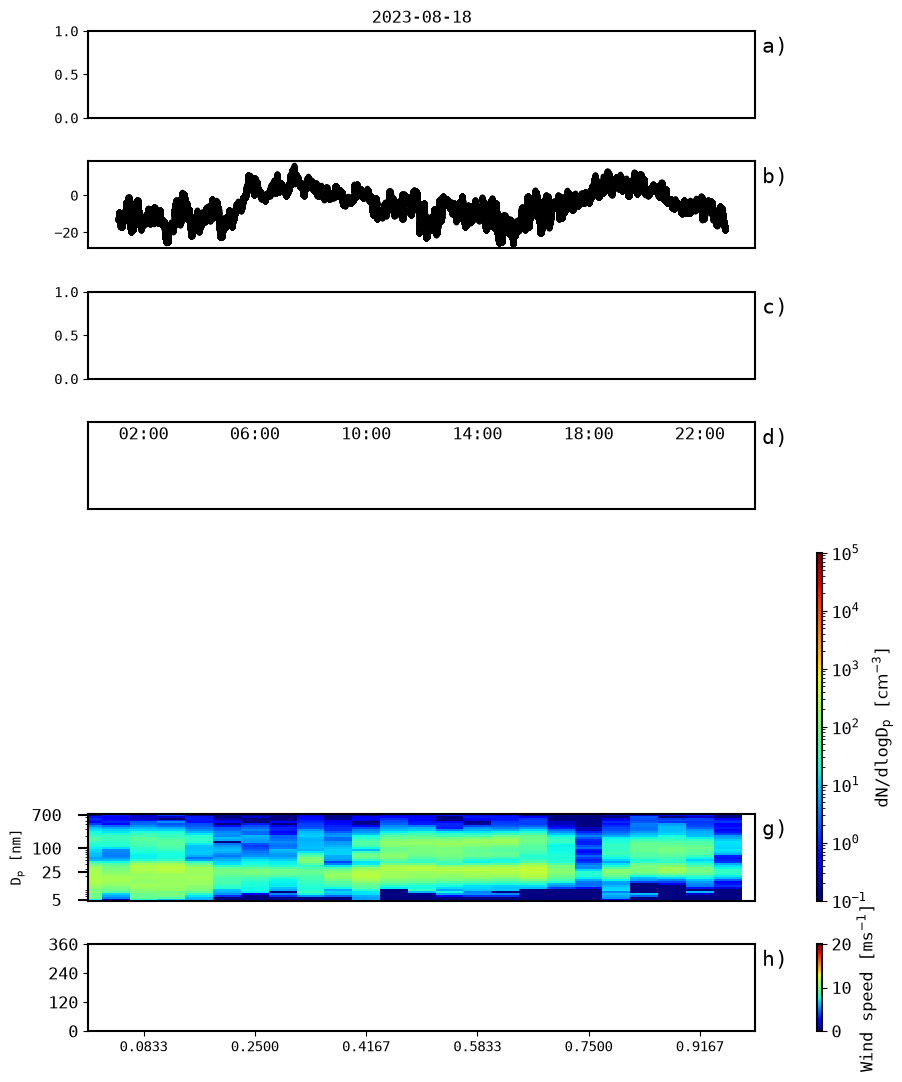

In [103]:
date = '2023-08-18'
fig = plot_decoupled(event=str(date), ZEP_files=ZEP_files, df_temp=df_temp_resampled, df_vis=df_vis,
                    ds_dmps_2022_2024=ds_dmps, polarity='neg', add_cf=False)

savepath_incloudevent=r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots\incloud_event'
save_plot(fig, path=savepath_incloudevent, folder='', name=str(date)+'_incloud', format_of_plot='.jpeg', dpi=300)

# Windblown: 

In [ ]:
number_of_data_points = df_wind_resampled[['windblown', 'date']].groupby('date').count()['windblown']
sum_of_windblown_points = df_wind_resampled[['windblown', 'date']].groupby('date').sum()['windblown']

df_percentage_windblown = sum_of_windblown_points/number_of_data_points

df_percentage_windblown = df_percentage_windblown.to_frame()
df_percentage_windblown['number_of_points'] = number_of_data_points
df_percentage_windblown['sum_of_windblown_points'] = sum_of_windblown_points

df_percentage_windblown = df_percentage_windblown[df_percentage_windblown>0]
df_percentage_windblown = df_percentage_windblown.dropna(how='any')

df_percentage_windblown = df_percentage_windblown.sort_values('windblown', ascending=False)

In [ ]:
dates = df_percentage_windblown.index

current_dir = os.getcwd()
inpath_files = current_dir+"\\ZEP_processed_files"
files = glob.glob(inpath_files+'\\*.nc')

outpath_plots=current_dir+"\\plots\\daily_plots\\windblown"

for date in dates[:10]: #top windiest
    try:
        open_and_plot(file=None, files=files, date=str(date), outpath_plots=outpath_plots)
    except ValueError:
        print(date)

# Better plots: 

In [ ]:
def box_plot_size_distribution(df, Dp, title='', savename='', ax=None):    
    if ax == None:
        ax = plt.subplot(1,1,1)      
        fig = plt.figure(num=None, figsize=(17, 7))

    boxprops = dict(linestyle='-', linewidth=2, color='k')
    color={'medians': 'red', 'boxes': 'grey', 'whiskers': 'grey', 'caps': 'grey'}
    
    medianprops = dict(linestyle='-', linewidth=4, color='r')
    meanpointprops = dict(marker='o', markeredgecolor='black', markerfacecolor='black')
    whiskerprops = dict(linewidth=2)
    capprops = dict(linewidth=2)

    w = 0.01
    positions=Dp

    width = lambda p, w: 10**(np.log10(p)+w/2.)-10**(np.log10(p)-w/2.)

    boxplots = df.boxplot(showfliers=False, positions=positions, widths=width(positions,w), whiskerprops=whiskerprops, 
                          capprops=capprops, grid=False, meanprops=meanpointprops, meanline=False,
                          showmeans=True, boxprops=boxprops, medianprops=medianprops, color=color,
                          ax=ax)

    quantiles = df.quantile([0.25, 0.50, 0.75])
    ax.plot(Dp, quantiles.loc[0.25].values, ':', color='None')
    ax.plot(Dp, quantiles.loc[0.75].values, ':', color='None')
    ax.fill_between(Dp, quantiles.loc[0.75].values, quantiles.loc[0.25].values, 
                    where=(quantiles.loc[0.25].values < quantiles.loc[0.75].values), interpolate=True, hatch='x', 
                    fc='r', alpha=0.1, label='25$^{\mathrm{th}}$ - 75$^{\mathrm{th}}$')
    
    ax.set_xscale("log")
    ax.set_ylabel(r'dN/dlogD$_{\mathrm{p}}$ [cm$^{-3}$]', fontsize=17)
    
    start = df.index[0].date()
    end = df.index[-1].date()
    ax.set_title(str(title)+' - period: '+str(start)+' - '+str(end), fontsize=17, loc='left')

    ax.grid(True, alpha=0.6)
    ax.set_xlabel(r'D$_{\mathrm{p}}$ [nm]', fontsize=17)
    ax.set_xscale('log')
    ax.set_xlim([1,45])
    ax.set_xticks([1,2,5,10,20,30,40])
    ax.set_xticklabels([1,2,5,10,20,30,40], fontsize=17)
    thickax(ax)

    handles, labels = plt.gca().get_legend_handles_labels()
    diamond = Line2D([0], [0], marker='o', color='k', label='mean',
                              markerfacecolor='k', markersize=5)
    line = Line2D([0], [0], label='median', color='r')
    handles.extend([diamond,line])
        
    ax.tick_params(labelsize=15, axis='both', which='major')
    ax.tick_params(labelsize=15, axis='both', which='minor')

    for tick in ax.xaxis.get_major_ticks():
        tick.label.set_fontsize(14) 
        tick.label.set_rotation('horizontal')
        
    plt.legend(handles=handles, frameon=False)
    return ax

In [ ]:
def turn_to_df_get_Dp(ds, var):
    df = ds[var].to_pandas()
    diam_name = df.columns.tolist()
    Dp = [x*10**9 for x in diam_name]
    return df, Dp

In [ ]:
fig = plt.figure(figsize=(12, 8))
gs = GridSpec(2, 2, hspace = .1, wspace = .2, top = 1, bottom = 0, left = 0, right = 1)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

df_NAIS_vis_outofcloud, Dp = turn_to_df_get_Dp(ds_NAIS_vis_outofcloud, var='neg_particles')
box_plot_size_distribution(df_NAIS_vis_outofcloud, Dp, ax=ax1)
df_NAIS_vis_incloud, Dp = turn_to_df_get_Dp(ds_NAIS_vis_incloud, var='neg_particles')
box_plot_size_distribution(df_NAIS_vis_incloud, Dp, ax=ax2)

plt.show()

In [ ]:
unique_dates = np.unique(ds_NAIS['time'].dt.date)

In [ ]:
for date in unique_dates[:1]:
    print(date)
    ds_NAIS_date = ds_NAIS.sel(time=date)
    #selected_data = data.sel(time=date_to_select)

Add new variable to xarray let it equal 1 if the variable 'visability' is less than 1000 and 0 if 'visability' is greater than 5000. np.nan for all other values. 

In [ ]:
ds_NAIS['incloud'] = xr.where((ds_NAIS['visiblty'] < 1000), 1,
                              xr.where((ds_NAIS['visiblty'] > 5000), 0, np.nan))

In [ ]:
ds_NAIS['incloud']

In [ ]:
data_array = ds_NAIS['incloud'].values
# Label consecutive zeros
labeled_array, num_features = label(data_array == 0)
# Assign a value to each group of zeros
group_values = np.arange(1, num_features + 1)  # Start from 1
ds_NAIS['grouped_outofcloud'] = xr.DataArray(np.where(labeled_array == 0, np.nan, labeled_array), dims=ds_NAIS['incloud'].dims)

In [ ]:
ds_NAIS['grouped_outofcloud']

In [ ]:
groups = (ds_NAIS['incloud'] == 1).cumsum(dim='time')
# Assign a unique label to each group of consecutive 1s
group_labels = groups.where(ds_NAIS['incloud'] == 1, other=0)
# Update the 'new_variable' variable with the group labels
ds_NAIS['incloud_grouped'] = group_labels

In [ ]:
ds_NAIS['incloud_grouped'].plot()
plt.show()

# Incloud: 

In [ ]:
incloud = ds_NAIS['incloud'] == 1
ds_incloud = ds_NAIS.where(incloud, drop=True)

In [ ]:
incloud_datetimes = ds_incloud.time.values

In [ ]:
df_inclouddatetimes = pd.DataFrame(index=incloud_datetimes)
df_inclouddatetimes['value'] = 1

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df_inclouddatetimes.index, df_inclouddatetimes['value'].values, marker='o', ms=1)
plt.title('Datetime Plot')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Nano